## Day9 Task -- Pandas Advanced + Visualization + SQL Essentials 

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3 

### Task 1 
Load the dataset and perform a quick audit of each table: shape, columns, data types, null values, duplicates, and unique counts.




#### Expected Output 
A short data-quality summary in markdown and code. 


In [3]:
customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")
orders = pd.read_csv("orders.csv")

In [4]:
print("customers shape : ",customers.shape)
print("products shape : ",products.shape)
print("orders shape : ",orders.shape)

customers shape :  (7, 5)
products shape :  (7, 5)
orders shape :  (14, 6)


In [5]:
customers.head()

,customer_id,customer_name,region,segment,join_date
0,C001,Asha Mehta,North,Consumer,2024-01-10
1,C002,Rahul Verma,South,Corporate,2024-02-15
2,C003,Priya Nair,East,Home Office,2024-03-20
3,C004,Imran Khan,West,Consumer,2024-04-05
4,C005,Neha Patel,North,Corporate,2024-04-18


In [6]:
products.head()

,product_id,product_name,category,unit_price,cost_price
0,P101,Laptop Pro,Electronics,75000.0,55000
1,P102,Office Chair,Furniture,12000.0,8000
2,P103,Wireless Mouse,Electronics,1500.0,900
3,P104,Desk Lamp,Furniture,2500.0,1400
4,P105,Monitor 24,Electronics,14000.0,10000


In [7]:
orders.head()

,order_id,order_date,customer_id,product_id,quantity,discount
0,O5001,2024-01-12,C001,P101,1,0.05
1,O5002,2024-01-18,C002,P102,2,0.10
2,O5003,2024-02-02,C003,P103,4,0.00
3,O5004,2024-02-20,C004,P105,2,0.08
4,O5005,2024-03-05,C005,P106,1,0.12


In [8]:
def audit_table(df, table_name):
    
    print(f"TABLE: {table_name}")

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

    print("\nUnique Values:")
    print(df.nunique())

    print("\n")

In [9]:
audit_table(customers, "CUSTOMERS")

TABLE: CUSTOMERS

Shape:
(7, 5)

Columns:
['customer_id', 'customer_name', 'region', 'segment', 'join_date']

Data Types:
customer_id      object
customer_name    object
region           object
segment          object
join_date        object
dtype: object

Missing Values:
customer_id      0
customer_name    1
region           0
segment          0
join_date        0
dtype: int64

Duplicate Rows:
0

Unique Values:
customer_id      7
customer_name    6
region           4
segment          3
join_date        7
dtype: int64




In [10]:
audit_table(products, "PRODUCTS")


TABLE: PRODUCTS

Shape:
(7, 5)

Columns:
['product_id', 'product_name', 'category', 'unit_price', 'cost_price']

Data Types:
product_id       object
product_name     object
category         object
unit_price      float64
cost_price        int64
dtype: object

Missing Values:
product_id      0
product_name    0
category        0
unit_price      1
cost_price      0
dtype: int64

Duplicate Rows:
0

Unique Values:
product_id      7
product_name    7
category        2
unit_price      6
cost_price      7
dtype: int64




In [11]:
audit_table(orders, "ORDERS")

TABLE: ORDERS

Shape:
(14, 6)

Columns:
['order_id', 'order_date', 'customer_id', 'product_id', 'quantity', 'discount']

Data Types:
order_id        object
order_date      object
customer_id     object
product_id      object
quantity         int64
discount       float64
dtype: object

Missing Values:
order_id       0
order_date     0
customer_id    0
product_id     0
quantity       0
discount       2
dtype: int64

Duplicate Rows:
1

Unique Values:
order_id       13
order_date     13
customer_id     7
product_id      7
quantity        5
discount        6
dtype: int64




In [12]:
summary = pd.DataFrame({

    "Table": ["Customers", "Products", "Orders"],

    "Rows": [
        customers.shape[0],
        products.shape[0],
        orders.shape[0]
    ],

    "Columns": [
        customers.shape[1],
        products.shape[1],
        orders.shape[1]
    ],

    "Missing Values": [
        customers.isnull().sum().sum(),
        products.isnull().sum().sum(),
        orders.isnull().sum().sum()
    ],

    "Duplicate Rows": [
        customers.duplicated().sum(),
        products.duplicated().sum(),
        orders.duplicated().sum()
    ]
})

summary

,Table,Rows,Columns,Missing Values,Duplicate Rows
0,Customers,7,5,1,0
1,Products,7,5,1,0
2,Orders,14,6,2,1


## Data Quality Summary

The dataset contains three related tables: customers, products, and orders.

Key findings:

1. The Customers table contains one missing customer name.
2. The Products table contains one missing unit price.
3. The Orders table contains two missing discount values.
4. One duplicate order record was identified in the Orders table.
5. Data types for date columns are currently stored as objects and will be converted during data cleaning.


### ===============================================================

## Task 2
Clean the data where needed. Standardize column names, 
fix data types, and handle missing values with a clear 
justification. 

#### Expected Output 
Cleaned DataFrames ready for analysis.

In [13]:
customers_clean = customers.copy()
products_clean = products.copy()
orders_clean = orders.copy()

##### Convert Data Type of Date columns object to datetime enables time-series

In [14]:
customers_clean["join_date"] = pd.to_datetime(customers_clean["join_date"])
orders_clean["order_date"] = pd.to_datetime(orders_clean["order_date"])


In [15]:
customers_clean.dtypes

customer_id              object
customer_name            object
region                   object
segment                  object
join_date        datetime64[ns]
dtype: object

In [16]:
orders_clean.dtypes

order_id               object
order_date     datetime64[ns]
customer_id            object
product_id             object
quantity                int64
discount              float64
dtype: object

In [17]:
# Handle Missing Customer Name
customers_clean["customer_name"] = customers_clean["customer_name"].fillna("Unknown customer")

In [18]:
customers_clean.isnull().sum()

customer_id      0
customer_name    0
region           0
segment          0
join_date        0
dtype: int64

In [19]:
# Handle Missing Product Price
median_price = products_clean["unit_price"].median()

In [20]:
products_clean["unit_price"]=products_clean["unit_price"].fillna(median_price)

In [21]:
products_clean.isnull().sum()

product_id      0
product_name    0
category        0
unit_price      0
cost_price      0
dtype: int64

In [22]:
# Handle Missing Discounts
orders_clean["discount"] = orders_clean["discount"].fillna(0)

In [23]:
orders_clean.isnull().sum()

order_id       0
order_date     0
customer_id    0
product_id     0
quantity       0
discount       0
dtype: int64

In [24]:
# Remove Duplicates in order table
orders_clean=orders_clean.drop_duplicates()

In [25]:
orders_clean.duplicated().sum()

np.int64(0)

### Data Cleaning Summary

The dataset was successfully cleaned and prepared for analysis.

Cleaning actions performed:


1. Converted date fields to datetime format.
2. Filled missing customer names with "Unknown Customer".
3. Replaced missing product prices with the median price.
4. Replaced missing discount values with 0.
5. Removed duplicate order records.



### ======================================================================

## Task 3
Use groupby to analyze sales by region, category, and 
customer segment. Include at least one multi-level groupby 
result. 

#### Expected Output 
Grouped summary tables with business 
interpretation. 

In [26]:
sales = (
    orders_clean
    .merge(customers_clean, on="customer_id", how="left")
    .merge(products_clean, on="product_id", how="left")
)
sales["revenue"] = sales["quantity"] * sales["unit_price"] * (1 - sales["discount"])
sales.head()

,order_id,order_date,customer_id,product_id,quantity,discount,customer_name,region,segment,join_date,product_name,category,unit_price,cost_price,revenue
0,O5001,2024-01-12,C001,P101,1,0.05,Asha Mehta,North,Consumer,2024-01-10,Laptop Pro,Electronics,75000.0,55000,71250.0
1,O5002,2024-01-18,C002,P102,2,0.10,Rahul Verma,South,Corporate,2024-02-15,Office Chair,Furniture,12000.0,8000,21600.0
2,O5003,2024-02-02,C003,P103,4,0.00,Priya Nair,East,Home Office,2024-03-20,Wireless Mouse,Electronics,1500.0,900,6000.0
3,O5004,2024-02-20,C004,P105,2,0.08,Imran Khan,West,Consumer,2024-04-05,Monitor 24,Electronics,14000.0,10000,25760.0
4,O5005,2024-03-05,C005,P106,1,0.12,Neha Patel,North,Corporate,2024-04-18,Standing Desk,Furniture,28000.0,21000,24640.0


In [27]:
sales.groupby("region")[["revenue","quantity"]].sum()

,revenue,quantity
region,,
East,55800.0,8
North,116315.0,6
South,150370.0,10
West,30760.0,4


In [28]:
sales.groupby("category")[["revenue","quantity"]].sum()

,revenue,quantity
category,,
Electronics,232560.0,17
Furniture,120685.0,11


In [29]:
sales.groupby("segment")[["revenue","quantity"]].sum()

,revenue,quantity
segment,,
Consumer,207155.0,18
Corporate,129290.0,5
Home Office,16800.0,5


In [30]:
sales.groupby(["region","category","segment"])[["revenue","quantity"]].sum()

revenue  quantity
region category    segment                       
East   Electronics Consumer     39000.0         3
                   Home Office   6000.0         4
       Furniture   Home Office  10800.0         1
North  Electronics Consumer     71250.0         1
                   Corporate    13300.0         1
       Furniture   Consumer      7125.0         3
                   Corporate    24640.0         1
South  Electronics Consumer      7500.0         5
                   Corporate    69750.0         1
       Furniture   Consumer     51520.0         2
                   Corporate    21600.0         2
West   Electronics Consumer     25760.0         2
       Furniture   Consumer      5000.0         2

In [31]:
     sales.groupby("region").agg(

        total_revenue=("revenue", "sum"),
        avg_revenue=("revenue", "mean"),
        total_orders=("order_id", "count"),
        total_quantity=("quantity", "sum"))
    

,total_revenue,avg_revenue,total_orders,total_quantity
region,,,,
East,55800.0,18600.00,3,8
North,116315.0,29078.75,4,6
South,150370.0,37592.50,4,10
West,30760.0,15380.00,2,4


### GroupBy Analysis Summary

Key observations:

1. Revenue varies significantly across regions.
2. Electronics and Furniture contribute differently to sales performance.
3. Customer segments show different purchasing behaviors.
4. The Region-Segment combination highlights the most profitable customer groups.

### ====================================================================

## Task 4
Merge the related tables and calculate key metrics such as 
total revenue, average order value, and top-selling 
products.

#### Expected Output
A merged analysis table with derived 
columns. 

In [40]:
merged_df = (
    orders_clean
    .merge(customers_clean, on="customer_id", how = "left")
    .merge(products_clean, on="product_id", how = "left")
)
merged_df.head()

,order_id,order_date,customer_id,product_id,quantity,discount,customer_name,region,segment,join_date,product_name,category,unit_price,cost_price
0,O5001,2024-01-12,C001,P101,1,0.05,Asha Mehta,North,Consumer,2024-01-10,Laptop Pro,Electronics,75000.0,55000
1,O5002,2024-01-18,C002,P102,2,0.10,Rahul Verma,South,Corporate,2024-02-15,Office Chair,Furniture,12000.0,8000
2,O5003,2024-02-02,C003,P103,4,0.00,Priya Nair,East,Home Office,2024-03-20,Wireless Mouse,Electronics,1500.0,900
3,O5004,2024-02-20,C004,P105,2,0.08,Imran Khan,West,Consumer,2024-04-05,Monitor 24,Electronics,14000.0,10000
4,O5005,2024-03-05,C005,P106,1,0.12,Neha Patel,North,Corporate,2024-04-18,Standing Desk,Furniture,28000.0,21000


In [41]:
merged_df["revenue"] = (merged_df["quantity"]*merged_df["unit_price"]*(1-merged_df["discount"]))
merged_df["cost"]= (merged_df["quantity"]*merged_df["cost_price"])
merged_df["profit"]= (merged_df["revenue"]-merged_df["cost"])

In [51]:
merged_df.head()

,order_id,order_date,customer_id,product_id,quantity,discount,customer_name,region,segment,join_date,product_name,category,unit_price,cost_price,revenue,cost,profit
0,O5001,2024-01-12,C001,P101,1,0.05,Asha Mehta,North,Consumer,2024-01-10,Laptop Pro,Electronics,75000.0,55000,71250.0,55000,16250.0
1,O5002,2024-01-18,C002,P102,2,0.10,Rahul Verma,South,Corporate,2024-02-15,Office Chair,Furniture,12000.0,8000,21600.0,16000,5600.0
2,O5003,2024-02-02,C003,P103,4,0.00,Priya Nair,East,Home Office,2024-03-20,Wireless Mouse,Electronics,1500.0,900,6000.0,3600,2400.0
3,O5004,2024-02-20,C004,P105,2,0.08,Imran Khan,West,Consumer,2024-04-05,Monitor 24,Electronics,14000.0,10000,25760.0,20000,5760.0
4,O5005,2024-03-05,C005,P106,1,0.12,Neha Patel,North,Corporate,2024-04-18,Standing Desk,Furniture,28000.0,21000,24640.0,21000,3640.0


In [53]:
print("total_revenue")
print(merged_df["revenue"].sum())

total_revenue
353245.0


In [55]:
print("total profit")
print(merged_df["profit"].sum())

total profit
107545.0


In [57]:
print("total orders")
print(merged_df["order_id"].nunique())

total orders
13


In [62]:
print("average order value")
print(merged_df["revenue"].sum()/merged_df["order_id"].nunique())

average order value
27172.69230769231


In [63]:
top_products = (
    merged_df
    .groupby("product_name")
    .agg(
        quantity_sold=("quantity", "sum"),
        revenue=("revenue", "sum")
    )
    .sort_values(
        by="revenue",
        ascending=False
    )
    .head(5)
)

top_products

,quantity_sold,revenue
product_name,,
Laptop Pro,2,141000.0
Standing Desk,3,76160.0
Monitor 24,3,39060.0
Keyboard,3,39000.0
Office Chair,3,32400.0


### Analysis Summary

The merged dataset provides a complete view of business performance.

Key findings:

1. Total Revenue measures overall sales generated.
2. Total Profit indicates actual earnings after product costs.
3. Average Order Value shows the average spending per order.
4. Top-selling products contribute the highest share of revenue.
   
These KPIs help management evaluate performance,
identify profitable products, and support strategic decisions.

### =============================================================================

## Task 5
Create at least two pivot tables to compare performance 
across two dimensions, such as region vs month or 
category vs segment.

#### Expected Output 
Pivoted summaries that are easy to read. 

In [65]:
merged_df["month"] = (
    merged_df["order_date"]
    .dt.strftime("%Y-%m")
)

merged_df[["order_date", "month"]].head()

,order_date,month
0,2024-01-12,2024-01
1,2024-01-18,2024-01
2,2024-02-02,2024-02
3,2024-02-20,2024-02
4,2024-03-05,2024-03


In [66]:
pivot_region_month = pd.pivot_table(
    merged_df,
    values="revenue",
    index="region",
    columns="month",
    aggfunc="sum",
    fill_value=0
)

pivot_region_month

month,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06
region,,,,,,
East,0.0,6000.0,0.0,0.0,10800.0,39000.0
North,71250.0,0.0,31765.0,0.0,0.0,13300.0
South,21600.0,0.0,0.0,77250.0,0.0,51520.0
West,0.0,25760.0,0.0,0.0,5000.0,0.0


In [68]:
pivot_category_segment = pd.pivot_table(
    merged_df,
    values="revenue",
    index="category",
    columns="segment",
    aggfunc="sum",
    fill_value=0
)

pivot_category_segment

segment,Consumer,Corporate,Home Office
category,,,
Electronics,143510.0,83050.0,6000.0
Furniture,63645.0,46240.0,10800.0


#### Pivot Table Analysis Summary

Key observations:

1. Revenue distribution varies across regions and months.
2. Certain customer segments contribute more revenue than others.

### ===========================================================

## Task 6 
Build six visualizations from the same dataset using 
matplotlib and seaborn. Include histogram, scatter plot, bar 
chart, line chart, box plot, and heatmap. 

#### Expected Output 
Six clearly labeled charts with titles and 
legends. 

In [70]:
sns.set_style("whitegrid")

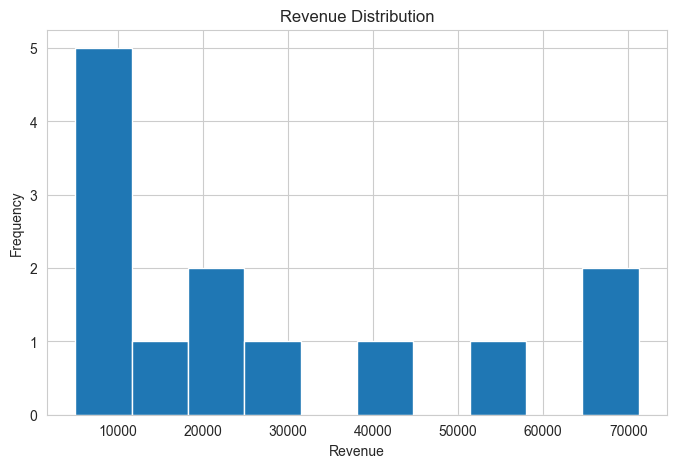

In [73]:
plt.figure(figsize=(8,5))

plt.hist(
    merged_df["revenue"],
    bins=10
)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

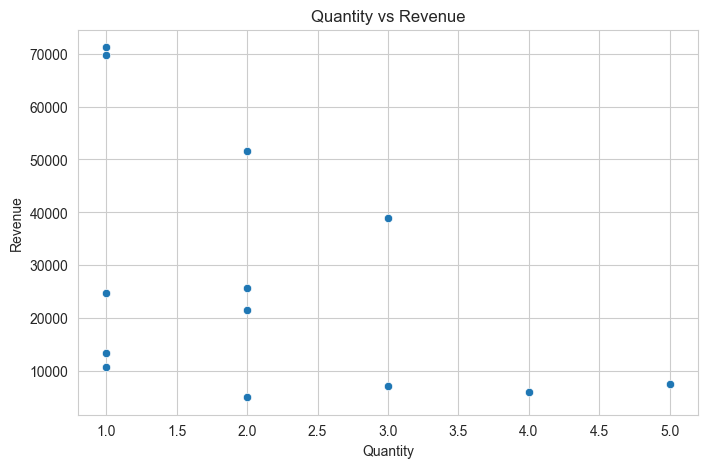

In [74]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=merged_df,
    x="quantity",
    y="revenue"
)

plt.title("Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")

plt.show()

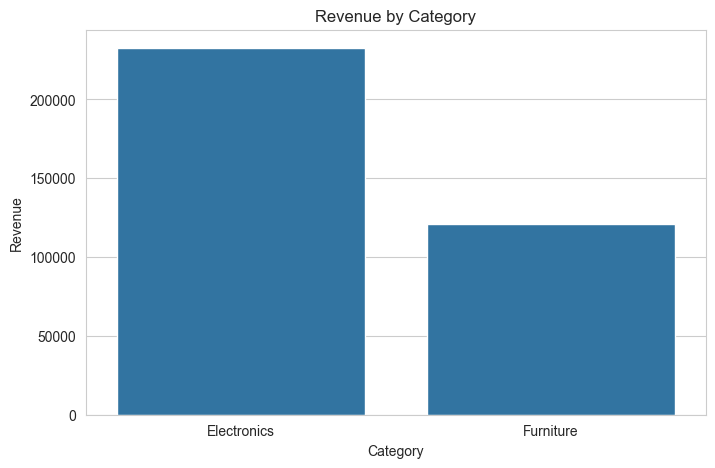

In [75]:
category_revenue = (
    merged_df
    .groupby("category")["revenue"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=category_revenue,
    x="category",
    y="revenue"
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

In [76]:
monthly_sales = (
    merged_df
    .groupby("month")["revenue"]
    .sum()
    .reset_index()
)

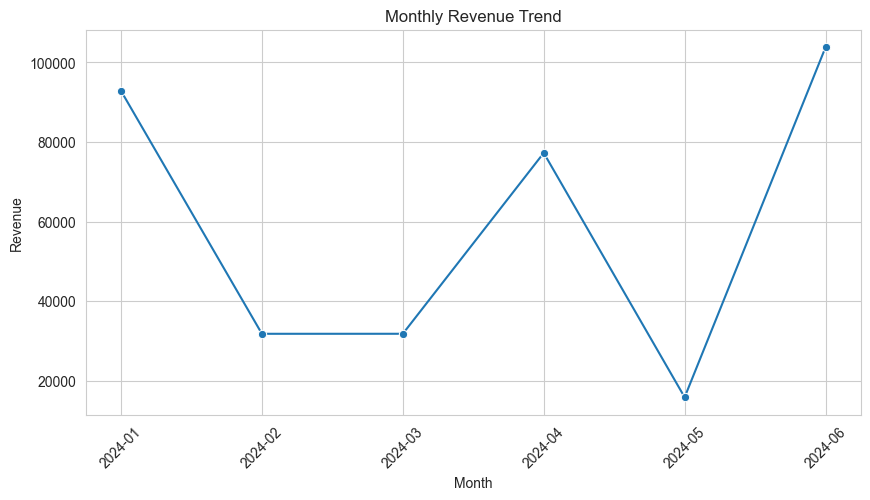

In [77]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_sales,
    x="month",
    y="revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

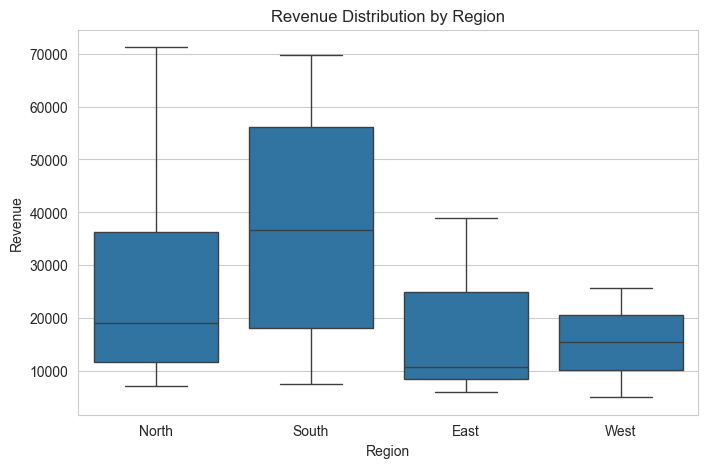

In [78]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged_df,
    x="region",
    y="revenue"
)

plt.title("Revenue Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")

plt.show()

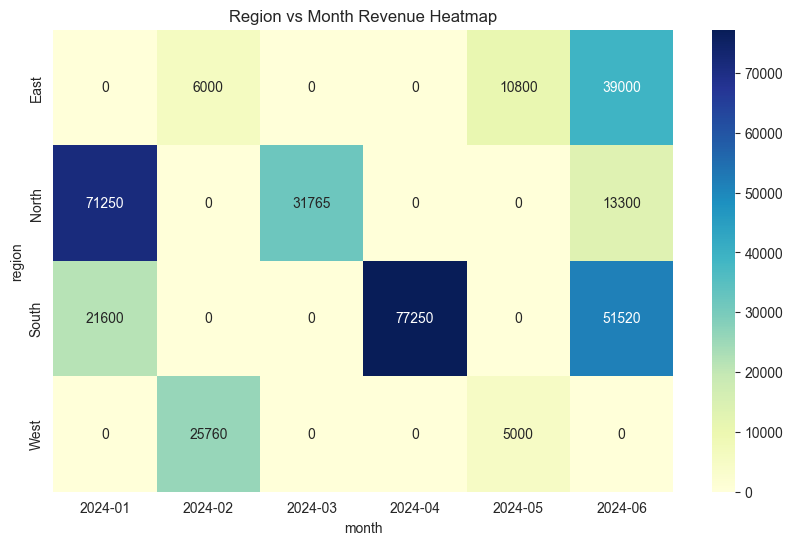

In [81]:
plt.figure(figsize=(10,6))

sns.heatmap(
    pivot_region_month,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Region vs Month Revenue Heatmap")

plt.show()

### Visualization Summary

Six visualizations were created to analyze sales performance.

Key visual analyses include:

1. Revenue distribution across orders.
2. Relationship between quantity and revenue.
3. Category-wise revenue comparison.
4. Monthly revenue trends.
5. Regional revenue variation.
6. Revenue patterns across regions and months.

These visualizations provide a clear understanding of business performance and support data-driven decision-making.

### ======================================================================

## Task 7
Write a short chart story: explain three insights you can 
infer from the charts in 5-8 sentences.

#### Expected Output 
A concise business narrative based on the 
visual output. 

###  Business Insights from Visualizations

The visualizations reveal several important business trends.

The revenue distribution histogram shows that most orders generate moderate revenue, while a few high-value transactions contribute significantly to total sales. The scatter plot indicates a positive relationship between quantity sold and revenue, suggesting that larger purchases generally lead to higher earnings. The category-wise bar chart highlights that one product category contributes more revenue than the other, making it a key driver of business performance.

The monthly revenue trend chart shows fluctuations in sales over time, indicating periods of stronger and weaker demand. The box plot reveals differences in revenue distribution across regions, suggesting that some regions consistently outperform others. Finally, the heatmap provides a clear view of regional sales patterns and helps identify high-performing region-month combinations.

Overall, the analysis suggests that focusing on top-performing categories, regions, and customer groups could help improve future revenue and profitability.

## Task 8
Create an SQLite database, load the tables, and write 15 
SQL queries covering SELECT, WHERE, GROUP BY, 
ORDER BY, JOINs, aggregates, and subqueries. 
#### Expected Output
A .sql file or notebook cell section with 
solved queries.

In [82]:
conn = sqlite3.connect("sales.db")

cursor = conn.cursor()

print("Database Created Successfully")

Database Created Successfully


In [92]:
customers_clean.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

products_clean.to_sql(
    "products",
    conn,
    if_exists="replace",
    index=False
)

orders_clean.to_sql(
    "orders",
    conn,
    if_exists="replace",
    index=False
)

print("Tables Loaded Successfully")

Tables Loaded Successfully


In [94]:
pd.read_sql("SELECT * FROM customers", conn)

,customer_id,customer_name,region,segment,join_date
0,C001,Asha Mehta,North,Consumer,2024-01-10 00:00:00
1,C002,Rahul Verma,South,Corporate,2024-02-15 00:00:00
2,C003,Priya Nair,East,Home Office,2024-03-20 00:00:00
3,C004,Imran Khan,West,Consumer,2024-04-05 00:00:00
4,C005,Neha Patel,North,Corporate,2024-04-18 00:00:00
5,C006,Vikram Singh,South,Consumer,2024-05-02 00:00:00
6,C007,Unknown customer,East,Consumer,2024-06-15 00:00:00


In [95]:
pd.read_sql("SELECT * FROM products;", conn)

,product_id,product_name,category,unit_price,cost_price
0,P101,Laptop Pro,Electronics,75000.0,55000
1,P102,Office Chair,Furniture,12000.0,8000
2,P103,Wireless Mouse,Electronics,1500.0,900
3,P104,Desk Lamp,Furniture,2500.0,1400
4,P105,Monitor 24,Electronics,14000.0,10000
5,P106,Standing Desk,Furniture,28000.0,21000
6,P107,Keyboard,Electronics,13000.0,1200


In [96]:
pd.read_sql("SELECT * FROM orders WHERE quantity > 2;", conn)

,order_id,order_date,customer_id,product_id,quantity,discount
0,O5003,2024-02-02 00:00:00,C003,P103,4,0.00
1,O5006,2024-03-14 00:00:00,C001,P104,3,0.05
2,O5007,2024-04-01 00:00:00,C006,P103,5,0.00
3,O5013,2024-06-25 00:00:00,C007,P107,3,0.00


In [97]:
pd.read_sql("SELECT * FROM products ORDER BY unit_price DESC;", conn)

,product_id,product_name,category,unit_price,cost_price
0,P101,Laptop Pro,Electronics,75000.0,55000
1,P106,Standing Desk,Furniture,28000.0,21000
2,P105,Monitor 24,Electronics,14000.0,10000
3,P107,Keyboard,Electronics,13000.0,1200
4,P102,Office Chair,Furniture,12000.0,8000
5,P104,Desk Lamp,Furniture,2500.0,1400
6,P103,Wireless Mouse,Electronics,1500.0,900


In [98]:
pd.read_sql("SELECT COUNT(*) AS total_orders FROM orders;", conn)

,total_orders
0,13


In [99]:
pd.read_sql("""
SELECT
    p.product_name,
    SUM(o.quantity * p.unit_price * (1 - o.discount)) AS revenue
FROM orders o
JOIN products p
ON o.product_id = p.product_id
GROUP BY p.product_name
ORDER BY revenue DESC;
""", conn)

,product_name,revenue
0,Laptop Pro,141000.0
1,Standing Desk,76160.0
2,Monitor 24,39060.0
3,Keyboard,39000.0
4,Office Chair,32400.0
5,Wireless Mouse,13500.0
6,Desk Lamp,12125.0


In [100]:
pd.read_sql("""
SELECT
    c.region,
    SUM(o.quantity * p.unit_price * (1 - o.discount)) AS revenue
FROM orders o
JOIN customers c
ON o.customer_id = c.customer_id
JOIN products p
ON o.product_id = p.product_id
GROUP BY c.region
ORDER BY revenue DESC;
""", conn)

,region,revenue
0,South,150370.0
1,North,116315.0
2,East,55800.0
3,West,30760.0


In [101]:
pd.read_sql("""
SELECT
    customer_id,
    COUNT(*) AS total_orders
FROM orders
GROUP BY customer_id
ORDER BY total_orders DESC;
""", conn)

,customer_id,total_orders
0,C006,2
1,C005,2
2,C004,2
3,C003,2
4,C002,2
5,C001,2
6,C007,1


In [102]:
pd.read_sql("""
SELECT
    AVG(unit_price) AS average_price
FROM products;
""", conn)

,average_price
0,20857.142857


In [103]:
pd.read_sql("""
SELECT
    product_name,
    unit_price
FROM products
ORDER BY unit_price DESC
LIMIT 1;
""", conn)

,product_name,unit_price
0,Laptop Pro,75000.0


In [104]:
pd.read_sql("""
SELECT *
FROM customers
WHERE region = 'North';
""", conn)

,customer_id,customer_name,region,segment,join_date
0,C001,Asha Mehta,North,Consumer,2024-01-10 00:00:00
1,C005,Neha Patel,North,Corporate,2024-04-18 00:00:00


In [105]:
pd.read_sql("""
SELECT
    p.category,
    SUM(o.quantity * p.unit_price * (1 - o.discount)) AS revenue
FROM orders o
JOIN products p
ON o.product_id = p.product_id
GROUP BY p.category
ORDER BY revenue DESC;
""", conn)

,category,revenue
0,Electronics,232560.0
1,Furniture,120685.0


In [106]:
pd.read_sql("""
SELECT
    c.region,
    SUM(o.quantity * p.unit_price * (1 - o.discount)) AS revenue
FROM orders o
JOIN customers c
ON o.customer_id = c.customer_id
JOIN products p
ON o.product_id = p.product_id
GROUP BY c.region
HAVING revenue > 50000;
""", conn)

,region,revenue
0,East,55800.0
1,North,116315.0
2,South,150370.0


In [107]:
pd.read_sql("""
SELECT *
FROM (
    SELECT
        c.customer_name,
        SUM(o.quantity * p.unit_price * (1 - o.discount)) AS revenue
    FROM orders o
    JOIN customers c
    ON o.customer_id = c.customer_id
    JOIN products p
    ON o.product_id = p.product_id
    GROUP BY c.customer_name
)
ORDER BY revenue DESC
LIMIT 1;
""", conn)

,customer_name,revenue
0,Rahul Verma,91350.0


In [108]:
pd.read_sql("""
SELECT
    product_name,
    unit_price
FROM products
WHERE unit_price >
(
    SELECT AVG(unit_price)
    FROM products
);
""", conn)

,product_name,unit_price
0,Laptop Pro,75000.0
1,Standing Desk,28000.0


## Task 9 
Replicate one Pandas analysis in SQL and compare the 
result side-by-side, mentioning any differences in readability 
or flexibility.
#### Expected Output
A Pandas vs SQL comparison section.

In [124]:
pandas_region_revenue = (

    merged_df

    .groupby("region")["revenue"]

    .sum()

    .reset_index()

    .sort_values(
        by="revenue",
        ascending=False
    )

)

pandas_region_revenue

,region,revenue
2,South,150370.0
1,North,116315.0
0,East,55800.0
3,West,30760.0


In [125]:
sql_region_revenue = pd.read_sql("""

SELECT

    c.region,

    SUM(
        o.quantity *
        p.unit_price *
        (1 - o.discount)
    ) AS revenue

FROM orders o

JOIN customers c
ON o.customer_id = c.customer_id

JOIN products p
ON o.product_id = p.product_id

GROUP BY c.region

ORDER BY revenue DESC;

""", conn)

sql_region_revenue

,region,revenue
0,South,150370.0
1,North,116315.0
2,East,55800.0
3,West,30760.0


## Comparison of Pandas and SQL

Both Pandas and SQL produced identical revenue results for each region.

### Conclusion

Pandas is ideal for data analysis within Python notebooks, while SQL is more suitable for database-driven applications. Both tools are valuable and often used together in real-world data projects.

In [128]:
conn.close()